In [12]:
import pandas as pd

to_path = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\variable_terciario_anual_1998_2024.csv" 

df_terciario = pd.read_csv(to_path, sep=';')

In [13]:
import pandas as pd

to_path = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados_MES\reg_MES_banco_anual.csv"

df_mes = pd.read_csv(to_path)

In [14]:
import pandas as pd

to_path = r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\altman_mean_adj.csv"

df_altman = pd.read_csv(to_path, sep=';')

In [20]:
print(df_terciario.head()) #separado por ';'

     type        year ebitda_sales_ratio cambio_100 diferencia
0  retail  01/01/1998              0,157        NaN        NaN
1  retail  01/01/1999              0,161      0,025      0,004
2  retail  01/01/2000              0,086     -0,466     -0,075
3  retail  01/01/2001              0,159      0,849      0,073
4  retail  01/01/2002              0,158     -0,006     -0,001


In [21]:
print(df_mes.head()) #separado por comas

   rssd_id  MES_anual  year       tramo  HOL_anual  CAR_anual  LIQ_anual  \
0    12311   0.261086  1997  pre-crisis   0.030493   0.067649        NaN   
1    35301   0.406577  1997  pre-crisis   0.000028   0.057123        NaN   
2   122854   0.486343  1997  pre-crisis   0.101991   0.074794        NaN   
3   165628   0.273062  1997  pre-crisis   0.150438   0.076663        NaN   
4   210434   0.418127  1997  pre-crisis   0.090178   0.056870        NaN   

   NPL_anual  CIL_anual  WFUND_anual  ROA_anual  log_assets  
0   0.006486   0.164724          NaN   0.011756   -1.171183  
1   0.001130   0.060157          NaN   0.009871   -0.072571  
2   0.003155   0.073472          NaN   0.015346   -3.506558  
3   0.003223   0.100135          NaN   0.017210   -3.506558  
4   0.005920   0.156724          NaN   0.009777   -0.776529  


In [25]:
print(df_altman.head()) #separado por ';'

         year  sector z_score_adj  Unnamed: 3
0  01/01/1996  retail        6,85         NaN
1  01/01/1997  retail        8,67         NaN
2  01/01/1998  retail        8,41         NaN
3  01/01/1999  retail        7,19         NaN
4  01/01/2000  retail        6,29         NaN


In [24]:
renombres = {
    "altman_adj": "z_score_adj",
    "date":"year",
}
df_altman = df_altman.rename(columns=renombres)

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

# ── RUTAS ──────────────────────────────────────────────────────────────
path_altman    = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\altman_mean_adj.csv")
path_mes       = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados_MES\reg_MES_banco_anual.csv")
path_terciario = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\variable_terciario_anual_1998_2024.csv")
out_dir        = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados")
out_dir.mkdir(parents=True, exist_ok=True)

# ── 1. LEER LOS TRES CSV ───────────────────────────────────────────────
df_altman    = pd.read_csv(path_altman,    sep=";", engine="python")
df_mes       = pd.read_csv(path_mes)
df_terciario = pd.read_csv(path_terciario, sep=";", engine="python")

df_altman.columns    = df_altman.columns.str.strip()
df_mes.columns       = df_mes.columns.str.strip()
df_terciario.columns = df_terciario.columns.str.strip()

print("=== ALTMAN ===")
print(df_altman.head(3))
print(df_altman.dtypes)

print("\n=== MES ===")
print(df_mes.head(3))
print(df_mes.dtypes)

print("\n=== TERCIARIO ===")
print(df_terciario.head(3))
print(df_terciario.dtypes)

=== ALTMAN ===
         date  sector altman_adj  Unnamed: 3
0  01/01/1996  retail       6,85         NaN
1  01/01/1997  retail       8,67         NaN
2  01/01/1998  retail       8,41         NaN
date           object
sector         object
altman_adj     object
Unnamed: 3    float64
dtype: object

=== MES ===
   rssd_id  MES_anual  year       tramo  HOL_anual  CAR_anual  LIQ_anual  \
0    12311   0.261086  1997  pre-crisis   0.030493   0.067649        NaN   
1    35301   0.406577  1997  pre-crisis   0.000028   0.057123        NaN   
2   122854   0.486343  1997  pre-crisis   0.101991   0.074794        NaN   

   NPL_anual  CIL_anual  WFUND_anual  ROA_anual  log_assets  
0   0.006486   0.164724          NaN   0.011756   -1.171183  
1   0.001130   0.060157          NaN   0.009871   -0.072571  
2   0.003155   0.073472          NaN   0.015346   -3.506558  
rssd_id          int64
MES_anual      float64
year             int64
tramo           object
HOL_anual      float64
CAR_anual      float64

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

# ── RUTAS ──────────────────────────────────────────────────────────────
path_altman    = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\altman_mean_adj.csv")
path_mes       = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados_MES\reg_MES_banco_anual.csv")
path_terciario = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\variable_terciario_anual_1998_2024.csv")
out_dir        = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados")
out_dir.mkdir(parents=True, exist_ok=True)

# ── 1. LEER ────────────────────────────────────────────────────────────
df_altman    = pd.read_csv(path_altman,    sep=";", engine="python")
df_mes       = pd.read_csv(path_mes)
df_terciario = pd.read_csv(path_terciario, sep=";", engine="python")

df_altman.columns    = df_altman.columns.str.strip()
df_mes.columns       = df_mes.columns.str.strip()
df_terciario.columns = df_terciario.columns.str.strip()

# ── 2. LIMPIAR ALTMAN ──────────────────────────────────────────────────
df_altman["year"] = pd.to_datetime(df_altman["date"], dayfirst=True).dt.year

# altman_adj viene como object con coma decimal -> float
df_altman["altman_adj"] = (
    df_altman["altman_adj"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)
df_altman["altman_adj"] = pd.to_numeric(df_altman["altman_adj"], errors="coerce")

altman_clean = df_altman[["year", "sector", "altman_adj"]].copy()

# ── 3. LIMPIAR TERCIARIO ───────────────────────────────────────────────
df_terciario["year"] = pd.to_datetime(df_terciario["year"], dayfirst=True).dt.year

# diferencia viene como object con coma decimal -> float
df_terciario["diferencia"] = (
    df_terciario["diferencia"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)
df_terciario["diferencia"] = pd.to_numeric(df_terciario["diferencia"], errors="coerce")

terciario_clean = df_terciario[["year", "type", "diferencia"]].rename(columns={
    "type":       "sector",
    "diferencia": "delta_ebitda_sales"
})

# ── 4. MES MEDIO ANUAL ────────────────────────────────────────────────
mes_mean = (
    df_mes
    .groupby("year")["MES_anual"]
    .mean()
    .reset_index()
    .rename(columns={"MES_anual": "MES_t"})
)
mes_mean["year"] = mes_mean["year"].astype(int)

# ── 5. CONSTRUIR PANEL sector-año ─────────────────────────────────────
panel = (
    altman_clean
    .merge(terciario_clean, on=["year", "sector"], how="inner")
    .merge(mes_mean,        on="year",             how="left")
)

# Eliminar NaN en variables del modelo
vars_modelo = ["altman_adj", "delta_ebitda_sales", "MES_t"]
panel = panel.dropna(subset=vars_modelo).copy()

for col in vars_modelo:
    panel[col] = pd.to_numeric(panel[col], errors="coerce")
panel = panel.dropna(subset=vars_modelo)

# Variable de interacción: Δebitda/sales × MES_t
panel["inter_delta_MES"] = panel["delta_ebitda_sales"] * panel["MES_t"]

print(f"Panel shape: {panel.shape}")
print(panel["sector"].value_counts())
print(panel.head())

# ── 6. REGRESIÓN PRINCIPAL ─────────────────────────────────────────────
# Z_it = α + β1·Δebitda/sales + β2·MES_t + β3·(Δebitda/sales × MES_t)
#           + EF_sector + EF_año + ε_it

year_dummies   = pd.get_dummies(panel["year"],   prefix="yr",  drop_first=True).astype(float)
sector_dummies = pd.get_dummies(panel["sector"], prefix="sec", drop_first=True).astype(float)

X_main = panel[["delta_ebitda_sales", "MES_t", "inter_delta_MES"]].astype(float)
X      = pd.concat([X_main, sector_dummies, year_dummies], axis=1)
X      = sm.add_constant(X)
Y      = panel["altman_adj"].astype(float)

modelo = sm.OLS(Y, X).fit(cov_type="HC3")

# ── 7. MOSTRAR COEFICIENTES DE INTERÉS ────────────────────────────────
idx_main = [c for c in modelo.params.index
            if not c.startswith("yr_") and not c.startswith("sec_")]

print(f"\n{'='*65}")
print("REGRESIÓN: Z-Score Altman ~ Δebitda/sales + MES + interacción")
print(f"{'='*65}")
print(pd.DataFrame({
    "coef":    modelo.params[idx_main].round(4),
    "se":      modelo.bse[idx_main].round(4),
    "t":       modelo.tvalues[idx_main].round(3),
    "p_valor": modelo.pvalues[idx_main].round(3),
}).to_string())
print(f"\nR²={modelo.rsquared:.3f} | Adj.R²={modelo.rsquared_adj:.3f} | N={int(modelo.nobs)}")

# ── 8. CONTRASTE DE HIPÓTESIS ──────────────────────────────────────────
print(f"\n{'='*65}")
print("CONTRASTE DE HIPÓTESIS")
print(f"{'='*65}")

def resultado_h(nombre, beta, p, signo_esp):
    sig  = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.10 else "n.s."
    ok   = (beta > 0 and signo_esp == "+") or (beta < 0 and signo_esp == "-")
    res  = "✓ SOPORTADA" if (ok and p < 0.10) else "✗ NO SOPORTADA"
    print(f"  {nombre}: β={beta:.4f} (p={p:.3f} {sig}) → {res}")

resultado_h("H1 β1>0 (terciarización mejora Z-Score)",
            modelo.params["delta_ebitda_sales"],
            modelo.pvalues["delta_ebitda_sales"], "+")

resultado_h("H2 β2<0 (estrés MES reduce Z-Score)",
            modelo.params["MES_t"],
            modelo.pvalues["MES_t"], "-")

resultado_h("H3 β3<0 (interacción erosiona efecto positivo)",
            modelo.params["inter_delta_MES"],
            modelo.pvalues["inter_delta_MES"], "-")

# ── 9. GUARDAR ─────────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    "variable": idx_main,
    "coef":     modelo.params[idx_main].values,
    "se":       modelo.bse[idx_main].values,
    "t":        modelo.tvalues[idx_main].values,
    "p_valor":  modelo.pvalues[idx_main].values,
    "ci_low":   modelo.conf_int().loc[idx_main, 0].values,
    "ci_high":  modelo.conf_int().loc[idx_main, 1].values,
})
coef_df.to_csv(out_dir / "coef_regresion_final.csv", index=False)
panel.to_csv(out_dir  / "panel_regresion_final.csv",  index=False)
print(f"\nGuardados en: {out_dir}")

# ── 10. TABLA LaTeX ────────────────────────────────────────────────────
def stars_latex(p):
    if p<0.01: return "^{***}"
    elif p<0.05: return "^{**}"
    elif p<0.10: return "^{*}"
    return ""

var_labels = {
    "const":              "Constante",
    "delta_ebitda_sales": r"$\Delta$EBITDA/Sales ($\beta_1$)",
    "MES_t":              r"MES$_t$ ($\beta_2$)",
    "inter_delta_MES":    r"$\Delta$EBITDA/Sales $\times$ MES$_t$ ($\beta_3$)",
}

rows = []
for var in idx_main:
    c  = modelo.params[var]
    se = modelo.bse[var]
    p  = modelo.pvalues[var]
    lb = var_labels.get(var, var.replace("_", "\\_"))
    rows.append(f"{lb} & ${c:.4f}{stars_latex(p)}$ & $({se:.4f})$ \\\\")
    rows.append(r"& & \\[-6pt]")

stats = [
    f"N & {int(modelo.nobs)} & \\\\",
    f"$R^2$ & {modelo.rsquared:.3f} & \\\\",
    f"Adj. $R^2$ & {modelo.rsquared_adj:.3f} & \\\\",
    r"EF año & Sí & \\",
    r"EF sector & Sí & \\",
]

latex = (
    "\\begin{table}[htbp]\n\\centering\n"
    "\\caption{Regresión final: Z-Score de Altman $\\sim$ Terciarización, "
    "Estrés Sistémico e Interacción}\n"
    "\\label{tab:reg_final}\n"
    "\\begin{tabular}{lcc}\n\\toprule\n"
    "\\textbf{Variable} & \\textbf{Coef.} & \\textbf{(SE)} \\\\\n"
    "\\midrule\n" +
    "\n".join(rows) + "\n\\midrule\n" +
    "\n".join(stats) + "\n"
    "\\bottomrule\n"
    "\\multicolumn{3}{l}{\\footnotesize HC3 robust SE. "
    "$^{***}$p$<$0.01, $^{**}$p$<$0.05, $^{*}$p$<$0.10.} \\\\\n"
    "\\multicolumn{3}{l}{\\footnotesize "
    "H1: $\\beta_1>0$; H2: $\\beta_2<0$; H3: $\\beta_3<0$.} \\\\\n"
    "\\end{tabular}\n\\end{table}"
)

with open(out_dir / "tabla_regresion_final.tex", "w", encoding="utf-8") as f:
    f.write(latex)
print("Guardado: tabla_regresion_final.tex")

Panel shape: (84, 6)
sector
retail    21
energy    21
auto      21
teleco    21
Name: count, dtype: int64
   year  sector  altman_adj  delta_ebitda_sales     MES_t  inter_delta_MES
1  1999  retail        7.19               0.004  0.020282         0.000081
2  2000  retail        6.29              -0.075 -0.155396         0.011655
3  2001  retail        6.30               0.073  0.151835         0.011084
4  2002  retail        6.99              -0.001  0.066726        -0.000067
5  2003  retail        7.21              -0.042 -0.037379         0.001570

REGRESIÓN: Z-Score Altman ~ Δebitda/sales + MES + interacción
                       coef       se      t  p_valor
const                3.6379   0.5644  6.446    0.000
delta_ebitda_sales  -6.6425   4.6467 -1.430    0.153
MES_t                1.0498   0.4174  2.515    0.012
inter_delta_MES    -22.6137  30.5814 -0.739    0.460

R²=0.848 | Adj.R²=0.783 | N=84

CONTRASTE DE HIPÓTESIS
  H1 β1>0 (terciarización mejora Z-Score): β=-6.6425 (p=0.15

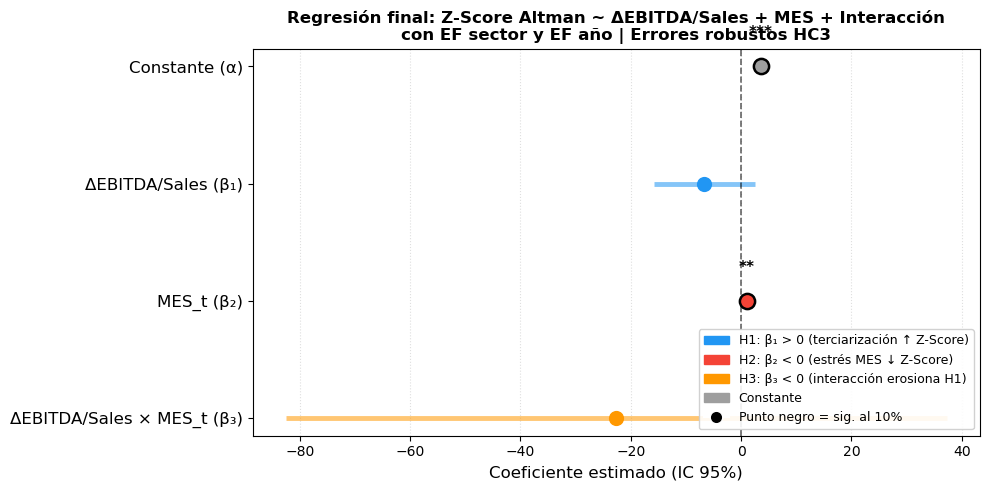

Guardado: D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados\coefplot_regresion_final.png


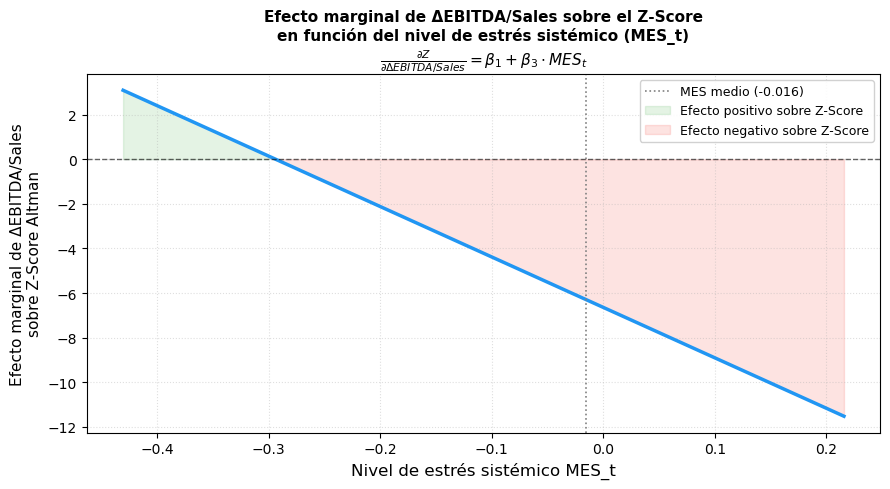

Guardado: D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados\efecto_marginal_regresion_final.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

out_dir = Path(r"D:\tfg_finance\mi_proyecto_datos\local_db\processed\resultados")
out_dir.mkdir(parents=True, exist_ok=True)

# ── Variables de interés (sin dummies) ────────────────────────────────
idx_main = [c for c in modelo.params.index
            if not c.startswith("yr_") and not c.startswith("sec_")]

var_labels = {
    "const":              "Constante (α)",
    "delta_ebitda_sales": "ΔEBITDA/Sales (β₁)",
    "MES_t":              "MES_t (β₂)",
    "inter_delta_MES":    "ΔEBITDA/Sales × MES_t (β₃)",
}

etiquetas = [var_labels.get(v, v) for v in idx_main]
coefs     = modelo.params[idx_main].values
ci_low    = modelo.conf_int().loc[idx_main, 0].values
ci_high   = modelo.conf_int().loc[idx_main, 1].values
pvals     = modelo.pvalues[idx_main].values

# ── Colores por hipótesis ──────────────────────────────────────────────
colores_h = {
    "const":              "#9E9E9E",   # gris (no es hipótesis)
    "delta_ebitda_sales": "#2196F3",   # azul → H1
    "MES_t":              "#F44336",   # rojo → H2
    "inter_delta_MES":    "#FF9800",   # naranja → H3
}
colores = [colores_h.get(v, "#9E9E9E") for v in idx_main]

# ── GRÁFICO PRINCIPAL: coefficient plot ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

y_pos = np.arange(len(idx_main))

for i, (coef, lo, hi, p, color) in enumerate(
        zip(coefs, ci_low, ci_high, pvals, colores)):

    # Barra IC 95%
    ax.hlines(i, lo, hi, color=color, linewidth=3.5, alpha=0.55)

    # Punto: relleno si p<0.10, hueco si no
    sig = p < 0.10
    ax.scatter(coef, i, color=color, s=120, zorder=5,
               edgecolors="black" if sig else color,
               linewidths=1.8 if sig else 0)

# Línea vertical en 0
ax.axvline(0, color="black", linewidth=1.2, linestyle="--", alpha=0.6)

# Etiquetas eje Y
ax.set_yticks(y_pos)
ax.set_yticklabels(etiquetas, fontsize=12)
ax.invert_yaxis()   # constante arriba, interacción abajo

# Anotaciones de p-valor junto a cada punto
for i, (coef, p) in enumerate(zip(coefs, pvals)):
    sig_str = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.10 else ""
    if sig_str:
        ax.text(coef, i - 0.25, sig_str, ha="center",
                fontsize=11, color="black", fontweight="bold")

# Leyenda de hipótesis
legend_elements = [
    mpatches.Patch(color="#2196F3", label="H1: β₁ > 0 (terciarización ↑ Z-Score)"),
    mpatches.Patch(color="#F44336", label="H2: β₂ < 0 (estrés MES ↓ Z-Score)"),
    mpatches.Patch(color="#FF9800", label="H3: β₃ < 0 (interacción erosiona H1)"),
    mpatches.Patch(color="#9E9E9E", label="Constante"),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='black',
               markersize=9, label="Punto negro = sig. al 10%"),
]
ax.legend(handles=legend_elements, fontsize=9,
          loc="lower right", framealpha=0.9)

ax.set_xlabel("Coeficiente estimado (IC 95%)", fontsize=12)
ax.set_title(
    "Regresión final: Z-Score Altman ~ ΔEBITDA/Sales + MES + Interacción\n"
    "con EF sector y EF año | Errores robustos HC3",
    fontsize=12, fontweight="bold"
)
ax.grid(axis="x", linestyle=":", alpha=0.4)

plt.tight_layout()

fig_path = out_dir / "coefplot_regresion_final.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado: {fig_path}")

# ── GRÁFICO SECUNDARIO: efecto marginal de ΔEBITDA/Sales según MES ────
# Muestra cómo varía el efecto de β1 a distintos niveles de MES_t

fig2, ax2 = plt.subplots(figsize=(9, 5))

b1 = modelo.params["delta_ebitda_sales"]
b3 = modelo.params["inter_delta_MES"]

# Rango de valores de MES (del mínimo al máximo observado)
mes_range = np.linspace(panel["MES_t"].min(), panel["MES_t"].max(), 100)

# Efecto marginal de Δebitda/sales = β1 + β3 * MES_t
efecto_marginal = b1 + b3 * mes_range

ax2.plot(mes_range, efecto_marginal, color="#2196F3", linewidth=2.5)
ax2.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.6)
ax2.axvline(panel["MES_t"].mean(), color="gray", linewidth=1.2,
            linestyle=":", label=f"MES medio ({panel['MES_t'].mean():.3f})")

# Zonas: efecto positivo vs negativo
ax2.fill_between(mes_range, efecto_marginal, 0,
                 where=(efecto_marginal >= 0),
                 alpha=0.15, color="#4CAF50", label="Efecto positivo sobre Z-Score")
ax2.fill_between(mes_range, efecto_marginal, 0,
                 where=(efecto_marginal < 0),
                 alpha=0.15, color="#F44336", label="Efecto negativo sobre Z-Score")

ax2.set_xlabel("Nivel de estrés sistémico MES_t", fontsize=12)
ax2.set_ylabel("Efecto marginal de ΔEBITDA/Sales\nsobre Z-Score Altman", fontsize=11)
ax2.set_title(
    "Efecto marginal de ΔEBITDA/Sales sobre el Z-Score\n"
    "en función del nivel de estrés sistémico (MES_t)\n"
    r"$\frac{\partial Z}{\partial \Delta EBITDA/Sales} = \beta_1 + \beta_3 \cdot MES_t$",
    fontsize=11, fontweight="bold"
)
ax2.legend(fontsize=9, framealpha=0.9)
ax2.grid(linestyle=":", alpha=0.4)

plt.tight_layout()

fig2_path = out_dir / "efecto_marginal_regresion_final.png"
plt.savefig(fig2_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado: {fig2_path}")